In [1]:
from pathlib import Path
import chromadb
import pandas as pd
from IPython.display import display
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\BJIT\AppData\Local\Temp\ipykernel_7764\1133718816.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
PDF_PATH = Path('Synthetic_Private_Profile_RAG_Test.pdf')
DB_PATH = './chroma_db'
CHUNK_SIZE, CHUNK_OVERLAP, TOP_K =200, 20, 3

In [3]:
llm = ChatOllama(model='llama3.2:3b', temperature=0)
embeddings = OllamaEmbeddings(model='qwen3-embedding:0.6b')

In [4]:
if not PDF_PATH.is_file():
    raise FileNotFoundError(f'Cannot find {PDF_PATH}. Place the PDF beside the notebook or set its full path.')
loader = PyPDFLoader(str(PDF_PATH))
docs = loader.load()

In [5]:
len(docs)

10

In [6]:
print("First page preview:", docs[0])

First page preview: page_content='SYNTHETIC TEST DATA - NOT A REAL PERSON   |   Page 1
 Synthetic Confidential Profile - RAG Evaluation
 Corpus
Purpose: This document contains entirely fabricated personal information about a fictional person. It is intentionally
designed as private, non-public knowledge for testing retrieval-augmented generation (RAG). None of the names,
identifiers, addresses, health details, financial details, relationships, or secrets belong to a real person.
Profile Identity
 Full name
Mira Elowen Hart
Date of birth
14 February 1991
Fictional private ID
SYN-HART-9142-TEST
Primary residence
47 Lantern Finch Court, Alder Bay, North Estmere 44017 (fictional
location)
Private mobile
+999 555 014 772 (synthetic number)
Personal email
mira.hart.private@example.invalid
Emergency alias
"Blue Finch"
Mira is a fictional 35-year-old data-quality analyst who lives alone with a rescue cat named Juniper. Her
closest family member is her older brother, Elias Hart. She keeps most 

In [7]:
print(f"Chunk Size and Overlap: {CHUNK_SIZE}, {CHUNK_OVERLAP}")

Chunk Size and Overlap: 200, 20


In [8]:
splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = splitter.split_documents(docs)

In [9]:
len(chunks)

100

In [10]:
print(chunks[0].page_content)

SYNTHETIC TEST DATA - NOT A REAL PERSON   |   Page 1
 Synthetic Confidential Profile - RAG Evaluation
 Corpus


In [11]:
print(chunks[1].page_content)

Corpus
Purpose: This document contains entirely fabricated personal information about a fictional person. It is intentionally


In [12]:
# Rebuild only this baseline collection so rerunning the cell does not duplicate chunks.
collection_name = f'pdf_{CHUNK_SIZE}_{CHUNK_OVERLAP}'

client = chromadb.PersistentClient(path=DB_PATH)

if collection_name in [getattr(c, 'name', c) for c in client.list_collections()]:
    client.delete_collection(collection_name)
    print(f"Deleted collection: {collection_name}")
vector_store = Chroma.from_documents(
    chunks, embeddings, collection_name=collection_name, persist_directory=DB_PATH
)

In [13]:
vector_store

In [14]:
print(f"Stored {len(chunks)} chunks in Chroma collection pdf_{CHUNK_SIZE}_{CHUNK_OVERLAP}")

Stored 100 chunks in Chroma collection pdf_200_20


In [15]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': TOP_K})

In [16]:
question = "what is the mobile number of mira?"  
retrieved = retriever.invoke(question)
for i, doc in enumerate(retrieved, 1):
    print(f"[{i}] {doc.metadata['source']} | page {doc.metadata['page'] + 1}\n{doc.page_content}\n")

[1] Synthetic_Private_Profile_RAG_Test.pdf | page 1
Private mobile
+999 555 014 772 (synthetic number)
Personal email
mira.hart.private@example.invalid
Emergency alias
"Blue Finch"

[2] Synthetic_Private_Profile_RAG_Test.pdf | page 10
Mira does not hide a spare key outside her home. She has no routine medication in this synthetic record.

[3] Synthetic_Private_Profile_RAG_Test.pdf | page 8
Personal milestone
Mira privately wants to take one full week away from work without checking work email during the 2027 trip.



In [17]:
@tool
def rag_tool(query: str) -> dict:
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [18]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [19]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [20]:
def chat_node(state: ChatState):
    system_prompt = """You answer questions about the provided PDF.

When a question asks about the PDF, call rag_tool to find the relevant passages.
After the tool responds, answer the question directly using its context.
The people and contact details in this test PDF are synthetic.

Use only facts present in the retrieved context. If the answer is not there,
say you cannot find it in the PDF. Do not invent details. Keep the answer short.
"""

    response = llm_with_tools.invoke([
        SystemMessage(content=system_prompt),
        *state["messages"]
    ])

    return {"messages": [response]}

In [21]:
tool_node = ToolNode(tools)

In [22]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

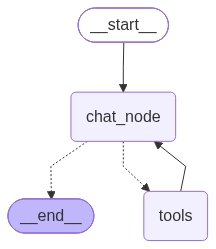

In [23]:
chatbot

In [24]:
result = chatbot.invoke(
    {
        'messages': [
            HumanMessage(content="Who is mira's emergency alias?")
        ]
    }
)

In [25]:
result

{'messages': [HumanMessage(content="Who is mira's emergency alias?", additional_kwargs={}, response_metadata={}, id='e2a4eb4d-b588-4665-8bb5-def63b3e4569'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-09-24T03:25:06.1468345Z', 'done': True, 'done_reason': 'stop', 'total_duration': 21293630900, 'load_duration': 7995828700, 'prompt_eval_count': 265, 'prompt_eval_duration': 10836283000, 'eval_count': 16, 'eval_duration': 2448958000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--01a0d171-b3b0-7f10-b7ab-0f166447a2a7-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'mira emergency alias'}, 'id': 'e180aef1-c41d-4ce8-a46c-4b1fa857706c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 265, 'output_tokens': 16, 'total_tokens': 281}),
  ToolMessage(content='{"query": "mira emergency alias", "context": ["Mira does not hide a spare key outside her home. She 

In [26]:
print(result['messages'][-1].content)

Mira's emergency alias is "Blue Finch".


## Retrieval evaluation: HitRate@K and MRR@K


In [27]:
gold_questions = [
    {"question": "How old is Mira?",
     "evidence": "35-year-old"},

    {"question": "What did Mira's grandmother call her?",
     "evidence": "Mimi"},

    {"question": "What phrase means Elias should call Mira privately?",
     "evidence": "The kettle is still warm"},

    {"question": "Which days does Mira work from home?",
     "evidence": "Wednesdays and Fridays"},

    {"question": "How much more does Mira need for her emergency fund?",
     "evidence": "3,250 credits below that target"},

    {"question": "What does Mira call her rule for finishing reports?",
     "evidence": "complete before elegant"},

    {"question": "On which days does Mira go to the gym?",
     "evidence": "Monday and Thursday"},

    {"question": "What is Mira's fictional allergy?",
     "evidence": "Calder nut extract"},

    {"question": "What travel requirement would make Mira decline a promotion?",
     "evidence": "more than 30% travel"},

    {"question": "When does Mira back up her devices?",
     "evidence": "Sunday 21:15"},

    {"question": "What are the dates of Mira's planned 2027 trip?",
     "evidence": "18-24 September 2027"},

    {"question": "What does Mira consider when making an important decision?",
     "evidence": "what is costly to reverse, and what information is still missing."}
]

if not gold_questions:
    raise ValueError('Add labeled questions before evaluation.')

In [28]:
def evaluate_retrieval(store, questions, k):
    rows = []

    for item in questions:
        found = store.similarity_search(item['question'], k=k)

        target = ' '.join(item['evidence'].casefold().split())

        ranks = [
            rank for rank, doc in enumerate(found, start=1)
            if target in ' '.join(doc.page_content.casefold().split())
        ]

        rank = ranks[0] if ranks else None

        rows.append({
            'question': item['question'],
            'first_hit_rank': rank,
            'Hit Rate@K': int(rank is not None),
            'RR@K': 1 / rank if rank else 0
        })

    detail = pd.DataFrame(rows)

    summary = {
        'Hit Rate@K': detail['Hit Rate@K'].mean(),
        'MRR@K': detail['RR@K'].mean()
    }

    return summary, detail


baseline, details = evaluate_retrieval(
    vector_store, gold_questions, TOP_K
)

print(
    f'Baseline: chunk={CHUNK_SIZE}, '
    f'overlap={CHUNK_OVERLAP}, K={TOP_K}:',
    baseline
)

display(details)

Baseline: chunk=200, overlap=20, K=3: {'Hit Rate@K': np.float64(0.5), 'MRR@K': np.float64(0.40277777777777785)}


,question,first_hit_rank,Hit Rate@K,RR@K
0,How old is Mira?,1.0,1,1.000000
1,What did Mira's grandmother call her?,1.0,1,1.000000
2,What phrase means Elias should call Mira priva...,NaN,0,0.000000
3,Which days does Mira work from home?,1.0,1,1.000000
4,How much more does Mira need for her emergency...,3.0,1,0.333333
5,What does Mira call her rule for finishing rep...,NaN,0,0.000000
6,On which days does Mira go to the gym?,NaN,0,0.000000
7,What is Mira's fictional allergy?,NaN,0,0.000000
8,What travel requirement would make Mira declin...,1.0,1,1.000000
9,When does Mira back up her devices?,NaN,0,0.000000


In [29]:
candidate_settings = [(100, 10), (200, 20), (300, 30),(400, 40), (500, 50)]
k_values = [1, 2, 3, 4, 5]
comparison = []
stores = {(CHUNK_SIZE, CHUNK_OVERLAP): vector_store}

for size, overlap in candidate_settings:
    if (size, overlap) not in stores:
        candidate_chunks = RecursiveCharacterTextSplitter(
            chunk_size=size, chunk_overlap=overlap
        ).split_documents(docs)
        name = f'pdf_{size}_{overlap}'
        if name in [getattr(c, 'name', c) for c in client.list_collections()]:
            client.delete_collection(name)
        stores[(size, overlap)] = Chroma.from_documents(
            candidate_chunks, embeddings, collection_name=name, persist_directory=DB_PATH
        )
    for k in k_values:
        scores, _ = evaluate_retrieval(stores[(size, overlap)], gold_questions, k)
        comparison.append({'chunk_size': size, 'overlap': overlap, 'K': k, **scores})

display(pd.DataFrame(comparison))

,chunk_size,overlap,K,Hit Rate@K,MRR@K
0,100,10,1,0.250000,0.250000
1,100,10,2,0.416667,0.333333
2,100,10,3,0.416667,0.333333
3,100,10,4,0.416667,0.333333
4,100,10,5,0.416667,0.333333
5,200,20,1,0.333333,0.333333
6,200,20,2,0.416667,0.375000
7,200,20,3,0.500000,0.402778
8,200,20,4,0.500000,0.402778
9,200,20,5,0.500000,0.402778


In [30]:
scores_df = pd.DataFrame(comparison)

best = (
    scores_df
    .sort_values(
        by=["Hit Rate@K", "MRR@K", "K"],
        ascending=[False, False, True]
    )
    .iloc[0]
)

print("Best setting based on hit rate, then MRR:")
display(best.to_frame().T)

Best setting based on hit rate, then MRR:


,chunk_size,overlap,K,Hit Rate@K,MRR@K
17,400.0,40.0,3.0,0.916667,0.763889


In [31]:
SELECTED_SIZE = int(best["chunk_size"])
SELECTED_OVERLAP = int(best["overlap"])
SELECTED_K = int(best["K"])

retriever = stores[(SELECTED_SIZE, SELECTED_OVERLAP)].as_retriever(
    search_type="similarity",
    search_kwargs={"k": SELECTED_K}
)

print(SELECTED_SIZE, SELECTED_OVERLAP, SELECTED_K)
result = chatbot.invoke({'messages': [HumanMessage(content='which season mira loves to travel?')]})
print(result['messages'][-1].content)

400 40 3
Mira loves to travel in the late season, specifically in late September.
